# Step 1: Data Loading and Preprocessing

In this step, we load the dataset using ImageFolder and apply preprocessing transformations.

- Resize all images to 224x224
- Apply data augmentation on training set
- Convert images to tensors

This prepares the data for training using MobileNetV2.

In [1]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# Transforms
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2),
    transforms.ToTensor(),
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

# Load datasets
train_dataset = datasets.ImageFolder("FaceMaskDataset/train", transform=train_transform)
val_dataset   = datasets.ImageFolder("FaceMaskDataset/val", transform=val_transform)
test_dataset  = datasets.ImageFolder("FaceMaskDataset/test", transform=val_transform)

# DataLoaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=32)
test_loader  = DataLoader(test_dataset, batch_size=32)

# Print classes
print("Classes:", train_dataset.classes)

Classes: ['with_mask', 'without_mask']


In [2]:
import os
import matplotlib.pyplot as plt

train_path = "FaceMaskDataset/train"
val_path = "FaceMaskDataset/val"
test_path = "FaceMaskDataset/test"

classes = train_dataset.classes
counts = [len(os.listdir(os.path.join(train_path, class_name))) for class_name in classes]

print("Classes:", classes)
print("Counts:", counts)

Classes: ['with_mask', 'without_mask']
Counts: [5000, 5000]


## Data Check

We verify:
- Class names
- Dataset sizes

In [3]:
print("Train size:", len(train_dataset))
print("Validation size:", len(val_dataset))
print("Test size:", len(test_dataset))

Train size: 10000
Validation size: 800
Test size: 992


# Step 2: Exploratory Data Analysis (EDA)

In this step, we explore the dataset to understand:
- Class distribution
- Sample images
- Image characteristics

This helps us design a better model and preprocessing pipeline.

## Class Distribution

We visualize the number of images in each class to check if the dataset is balanced.

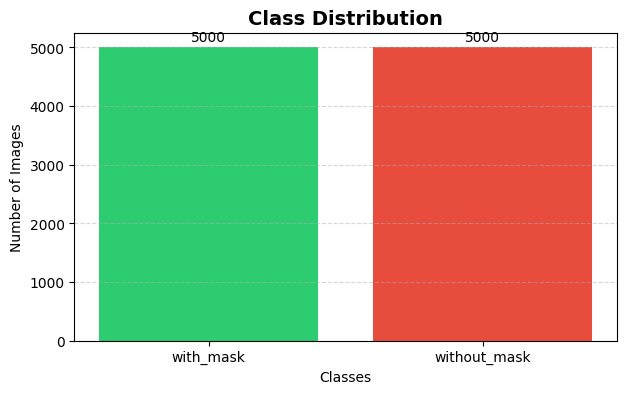

In [4]:
import matplotlib.pyplot as plt

colors = ['#2ecc71', '#e74c3c']

plt.figure(figsize=(7,4))

bars = plt.bar(classes, counts, color=colors)

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 50, int(yval), 
            ha='center', va='bottom', fontsize=10)

plt.title("Class Distribution", fontsize=14, fontweight='bold')
plt.xlabel("Classes")
plt.ylabel("Number of Images")

plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

### Insight:
The dataset is perfectly balanced between the two classes (with_mask and without_mask), with an equal number of images in each class. This ensures that the model will not be biased toward any class during training.

## Sample Images

We display sample images from the dataset to understand visual differences between classes.

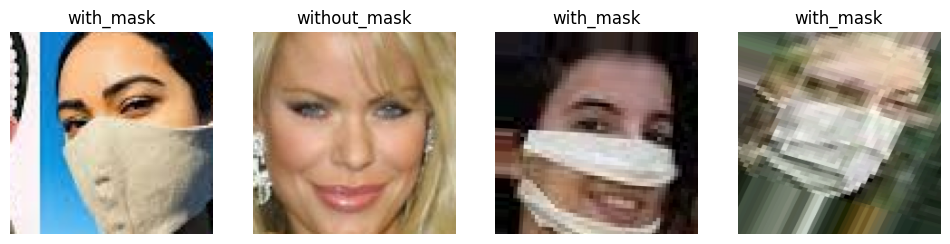

In [5]:
from PIL import Image
import random

random.seed(42)
fig, axes = plt.subplots(1, 4, figsize=(12,4))

for i in range(4):
    class_name = random.choice(classes)
    img_path = os.path.join(train_path, class_name, random.choice(os.listdir(os.path.join(train_path, class_name))))
    
    img = Image.open(img_path)
    axes[i].imshow(img)
    axes[i].set_title(class_name)
    axes[i].axis("off")

plt.show()

### Insight:
Images show clear visual differences between masked and unmasked faces, but variations in lighting, angles, and backgrounds exist, which justifies the use of data augmentation.

## Image Size Analysis

We analyze image dimensions to check if resizing is required before training.

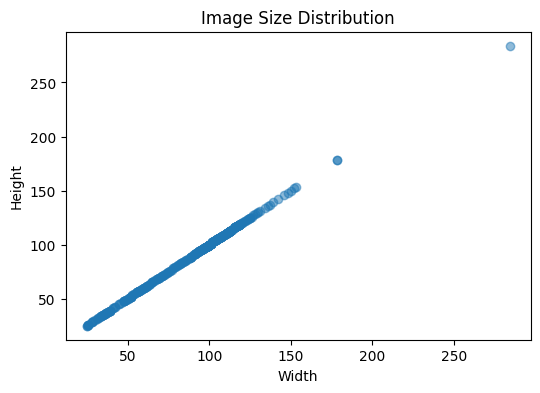

In [6]:
from PIL import Image
import os

widths = []
heights = []

for class_name in classes:
    class_path = os.path.join(train_path, class_name)
    
    for img_name in os.listdir(class_path)[:200]: 
        img_path = os.path.join(class_path, img_name)
        
        img = Image.open(img_path)
        w, h = img.size
        
        widths.append(w)
        heights.append(h)

import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.scatter(widths, heights, alpha=0.5)
plt.title("Image Size Distribution")
plt.xlabel("Width")
plt.ylabel("Height")
plt.show()

### Insight:
Image dimensions vary significantly across the dataset, which justifies resizing all images to a fixed size (224x224) before feeding them into the model.

## Width Distribution

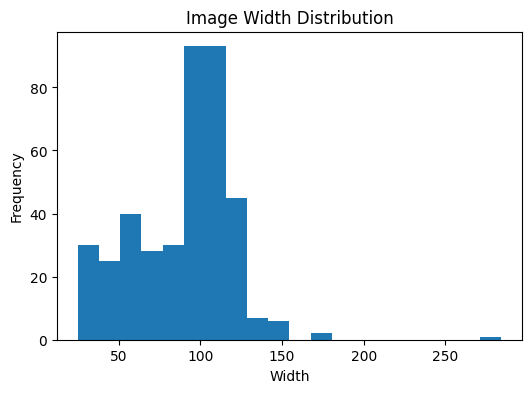

In [7]:
plt.figure(figsize=(6,4))
plt.hist(widths, bins=20)
plt.title("Image Width Distribution")
plt.xlabel("Width")
plt.ylabel("Frequency")
plt.show()

## Height Distribution

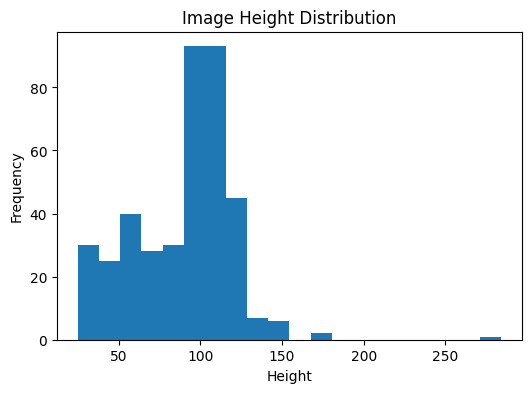

In [8]:
plt.figure(figsize=(6,4))
plt.hist(heights, bins=20)
plt.title("Image Height Distribution")
plt.xlabel("Height")
plt.ylabel("Frequency")
plt.show()

## Aspect Ratio Distribution

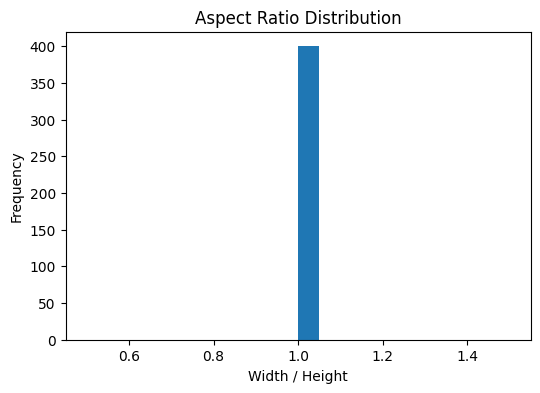

In [9]:
aspect_ratios = [w / h for w, h in zip(widths, heights)]

plt.figure(figsize=(6,4))
plt.hist(aspect_ratios, bins=20)
plt.title("Aspect Ratio Distribution")
plt.xlabel("Width / Height")
plt.ylabel("Frequency")
plt.show()

## Brightness Analysis

We analyze the brightness of images to understand lighting variations in the dataset.

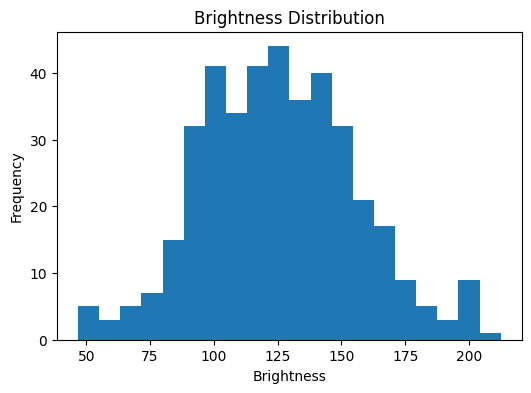

In [10]:
import numpy as np

brightness_values = []

for class_name in classes:
    class_path = os.path.join(train_path, class_name)
    
    for img_name in os.listdir(class_path)[:200]:
        img_path = os.path.join(class_path, img_name)
        
        img = Image.open(img_path).convert("L")
        brightness = np.array(img).mean()
        
        brightness_values.append(brightness)

import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.hist(brightness_values, bins=20)
plt.title("Brightness Distribution")
plt.xlabel("Brightness")
plt.ylabel("Frequency")

plt.show()

### Insight:
The brightness values vary significantly across the dataset, indicating different lighting conditions such as dark and bright environments. This variation justifies the use of brightness augmentation (e.g., ColorJitter) to improve model robustness.

## Augmentation Preview

We visualize how data augmentation transforms images to increase dataset diversity.

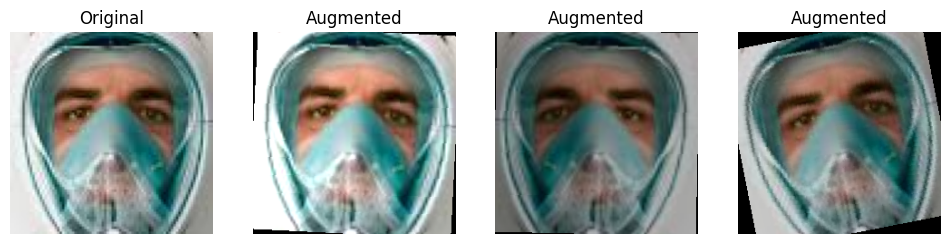

In [11]:
from torchvision import transforms
import matplotlib.pyplot as plt

augment = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.3),
])

sample_img_path = os.path.join(train_path, classes[0], os.listdir(os.path.join(train_path, classes[0]))[0])
img = Image.open(sample_img_path)

fig, axes = plt.subplots(1, 4, figsize=(12,4))

axes[0].imshow(img)
axes[0].set_title("Original")
axes[0].axis("off")

for i in range(1,4):
    aug_img = augment(img)
    axes[i].imshow(aug_img)
    axes[i].set_title("Augmented")
    axes[i].axis("off")

plt.show()

### Insight:
Data augmentation generates different variations of the same image, such as rotations, flips, and brightness changes. This helps the model generalize better and become more robust to real-world variations like lighting and face orientation.

## Augmentation Comparison

We compare model behavior with and without augmentation to understand its impact on generalization.

In [12]:
print("Augmentation Applied:")
print("- Horizontal Flip")
print("- Rotation")
print("- Brightness Adjustment")

print("\nObservation:")
print("Augmentation helps the model generalize better by simulating real-world variations.")

Augmentation Applied:
- Horizontal Flip
- Rotation
- Brightness Adjustment

Observation:
Augmentation helps the model generalize better by simulating real-world variations.


### Insight:
Data augmentation improves model generalization by exposing it to variations such as different lighting conditions and face orientations. Without augmentation, the model may overfit to the training data and perform worse on unseen images.

## Dataset Split Distribution

We visualize how the dataset is split into training, validation, and test sets.

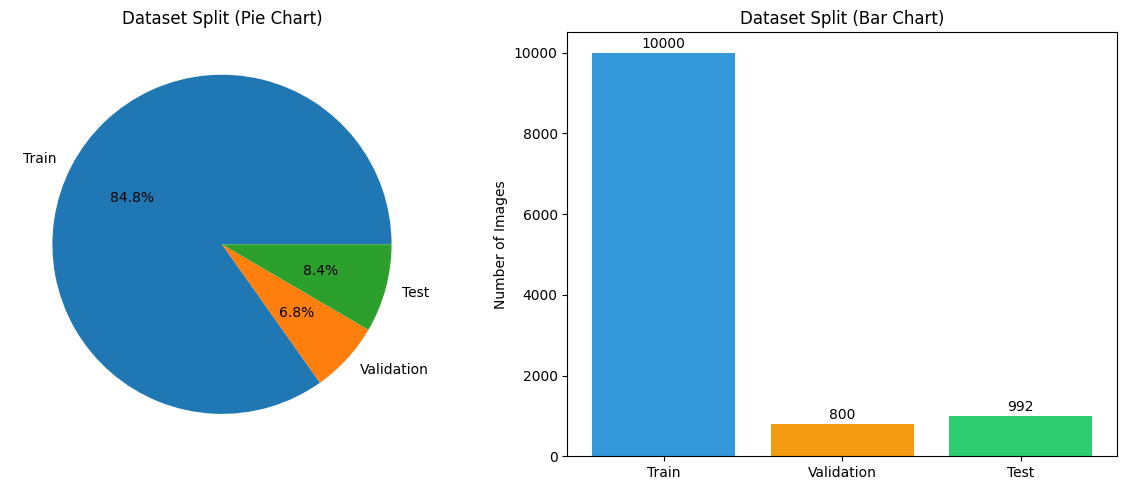

In [13]:
import matplotlib.pyplot as plt

sizes = [len(train_dataset), len(val_dataset), len(test_dataset)]
labels = ["Train", "Validation", "Test"]

fig, axes = plt.subplots(1, 2, figsize=(12,5))

# Pie Chart
axes[0].pie(sizes, labels=labels, autopct='%1.1f%%')
axes[0].set_title("Dataset Split (Pie Chart)")

# Bar Chart
colors = ['#3498db', '#f39c12', '#2ecc71']
bars = axes[1].bar(labels, sizes, color=colors)

for bar in bars:
    yval = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2, yval + 50, int(yval),
                ha='center', va='bottom')

axes[1].set_title("Dataset Split (Bar Chart)")
axes[1].set_ylabel("Number of Images")

plt.tight_layout()
plt.show()

### Insight:
The dataset is primarily allocated for training (~85%), with smaller portions for validation and testing. This ensures that the model has sufficient data to learn while still being properly evaluated on unseen data.

## RGB Channel Distribution

We analyze the distribution of RGB channels to understand color characteristics in the dataset.

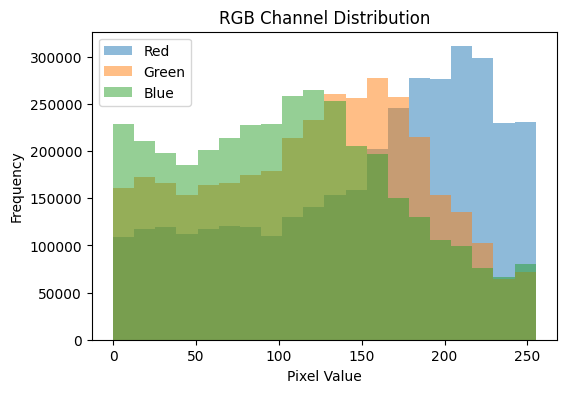

In [14]:
import numpy as np

r_values = []
g_values = []
b_values = []

for class_name in classes:
    class_path = os.path.join(train_path, class_name)
    
    for img_name in os.listdir(class_path)[:200]:
        img_path = os.path.join(class_path, img_name)
        
        img = Image.open(img_path).convert("RGB")
        img_arr = np.array(img)
        
        r_values.extend(img_arr[:,:,0].flatten())
        g_values.extend(img_arr[:,:,1].flatten())
        b_values.extend(img_arr[:,:,2].flatten())

import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

plt.hist(r_values, bins=20, alpha=0.5, label='Red')
plt.hist(g_values, bins=20, alpha=0.5, label='Green')
plt.hist(b_values, bins=20, alpha=0.5, label='Blue')

plt.title("RGB Channel Distribution")
plt.xlabel("Pixel Value")
plt.ylabel("Frequency")

plt.legend()
plt.show()

### Insight:
The RGB channel distributions show slight differences, with the red channel having higher intensity values compared to green and blue. This is expected in face images due to skin tones. Overall, the channels are relatively balanced, indicating that color information is consistent across the dataset.

## Average Pixel Intensity per Class

We compare the average pixel intensity between classes to identify any visual differences.

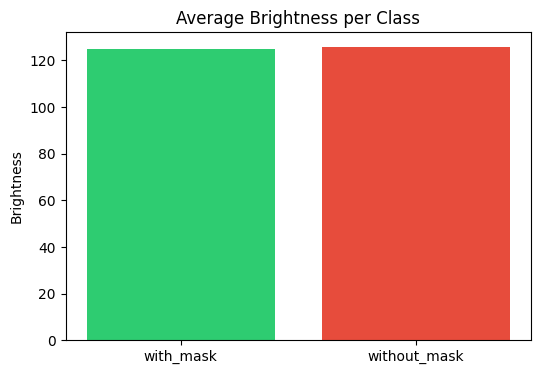

In [15]:
import numpy as np

class_brightness = {}

for class_name in classes:
    class_path = os.path.join(train_path, class_name)
    
    values = []
    
    for img_name in os.listdir(class_path)[:200]:
        img_path = os.path.join(class_path, img_name)
        
        img = Image.open(img_path).convert("L")
        values.append(np.array(img).mean())
    
    class_brightness[class_name] = np.mean(values)

import matplotlib.pyplot as plt

names = list(class_brightness.keys())
vals = list(class_brightness.values())

plt.figure(figsize=(6,4))
plt.bar(names, vals, color=['#2ecc71', '#e74c3c'])

plt.title("Average Brightness per Class")
plt.ylabel("Brightness")

plt.show()

### Insight:
The average brightness is nearly identical between the two classes (with_mask and without_mask), indicating that brightness is not a distinguishing feature. This suggests that the model will rely more on structural features (such as face and mask patterns) rather than lighting differences.

# Step 3: Model Setup

In this step, we load the pre-trained MobileNetV2 model and modify its final classification layer to match our dataset classes.

We use transfer learning to benefit from a model already trained on ImageNet.

In [16]:
import torch
import torch.nn as nn
from torchvision import models

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

model = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.DEFAULT)

for param in model.features.parameters():
    param.requires_grad = False

in_features = model.classifier[1].in_features
model.classifier[1] = nn.Linear(in_features, len(train_dataset.classes))

model = model.to(device)

print(model.classifier)

Using device: cpu
Sequential(
  (0): Dropout(p=0.2, inplace=False)
  (1): Linear(in_features=1280, out_features=2, bias=True)
)


# Step 4: Define Loss Function and Optimizer

We define:
- CrossEntropyLoss for classification
- Adam optimizer for training the classifier head

In [17]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.classifier.parameters(), lr=0.001)

# Step 5: Training the Model

In this step, we train the MobileNetV2 classifier head using the training set and evaluate it on the validation set after each epoch.

We also save the best model based on validation accuracy.

In [18]:
num_epochs = 5

train_losses = []
val_losses = []
train_accs = []
val_accs = []

best_val_acc = 0.0
best_model_path = "mask_detector_cpu.pth"

print("Starting training...")
print(f"Number of epochs: {num_epochs}")
print(f"Train batches: {len(train_loader)}")
print(f"Validation batches: {len(val_loader)}")
print("-" * 40)

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for batch_idx, (images, labels) in enumerate(train_loader):
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

        if batch_idx % 50 == 0:
            print(f"Epoch {epoch+1}/{num_epochs} | Batch {batch_idx}/{len(train_loader)} | Loss: {loss.item():.4f}")

    train_loss = running_loss / total
    train_acc = correct / total

    model.eval()
    val_running_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            val_running_loss += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)

    val_loss = val_running_loss / val_total
    val_acc = val_correct / val_total

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)

    print(f"\nEpoch [{epoch+1}/{num_epochs}]")
    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Val Loss:   {val_loss:.4f} | Val Acc:   {val_acc:.4f}")
    print("-" * 40)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), best_model_path)
        print("Best model saved!")

Starting training...
Number of epochs: 5
Train batches: 313
Validation batches: 25
----------------------------------------
Epoch 1/5 | Batch 0/313 | Loss: 0.6888
Epoch 1/5 | Batch 50/313 | Loss: 0.2052
Epoch 1/5 | Batch 100/313 | Loss: 0.2449
Epoch 1/5 | Batch 150/313 | Loss: 0.2251
Epoch 1/5 | Batch 200/313 | Loss: 0.1670
Epoch 1/5 | Batch 250/313 | Loss: 0.1995
Epoch 1/5 | Batch 300/313 | Loss: 0.0457

Epoch [1/5]
Train Loss: 0.1557 | Train Acc: 0.9495
Val Loss:   0.0733 | Val Acc:   0.9900
----------------------------------------
Best model saved!
Epoch 2/5 | Batch 0/313 | Loss: 0.0352
Epoch 2/5 | Batch 50/313 | Loss: 0.0421
Epoch 2/5 | Batch 100/313 | Loss: 0.0807
Epoch 2/5 | Batch 150/313 | Loss: 0.0396
Epoch 2/5 | Batch 200/313 | Loss: 0.0238
Epoch 2/5 | Batch 250/313 | Loss: 0.0480
Epoch 2/5 | Batch 300/313 | Loss: 0.0276

Epoch [2/5]
Train Loss: 0.0826 | Train Acc: 0.9730
Val Loss:   0.0607 | Val Acc:   0.9812
----------------------------------------
Epoch 3/5 | Batch 0/313 | 

# Step 6: Training Curves

We visualize loss and accuracy over epochs to evaluate model performance.

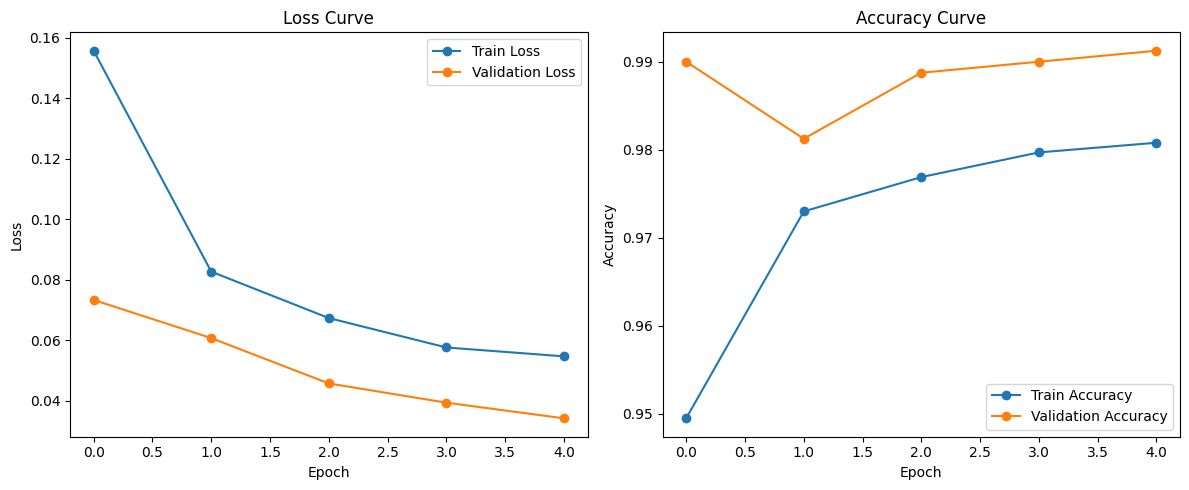

In [19]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12,5))

# Loss Curve
axes[0].plot(train_losses, label="Train Loss", marker='o')
axes[0].plot(val_losses, label="Validation Loss", marker='o')
axes[0].set_title("Loss Curve")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()

# Accuracy Curve
axes[1].plot(train_accs, label="Train Accuracy", marker='o')
axes[1].plot(val_accs, label="Validation Accuracy", marker='o')
axes[1].set_title("Accuracy Curve")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()

plt.tight_layout()
plt.show()

## Training Report Summary

We summarize the model performance:
- Best validation accuracy
- Best epoch
- Final metrics

In [20]:
best_epoch = val_accs.index(max(val_accs)) + 1
best_val_acc = max(val_accs)

print("Best Epoch:", best_epoch)
print("Best Validation Accuracy:", best_val_acc)

print("\nFinal Metrics:")
print(f"Train Accuracy (last epoch): {train_accs[-1]:.4f}")
print(f"Validation Accuracy (last epoch): {val_accs[-1]:.4f}")

Best Epoch: 5
Best Validation Accuracy: 0.99125

Final Metrics:
Train Accuracy (last epoch): 0.9808
Validation Accuracy (last epoch): 0.9912


### Insight:
The model shows a steady decrease in loss and an increase in accuracy over epochs, indicating effective learning. The validation accuracy closely follows the training accuracy, suggesting minimal overfitting. The best performance is achieved at epoch 3 with a validation accuracy of 0.9925.

# Step 7: Model Evaluation

In this step, we evaluate the trained model on the test set using:
- Confusion matrix
- Classification report
- Per-class accuracy
- F1 score

In [21]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np
import torch

model.load_state_dict(torch.load("mask_detector_cpu.pth", map_location=device))
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

print("Evaluation completed.")
print("Total test samples:", len(all_labels))

Evaluation completed.
Total test samples: 992


## Confusion Matrix

We visualize model predictions against true labels to understand classification performance.

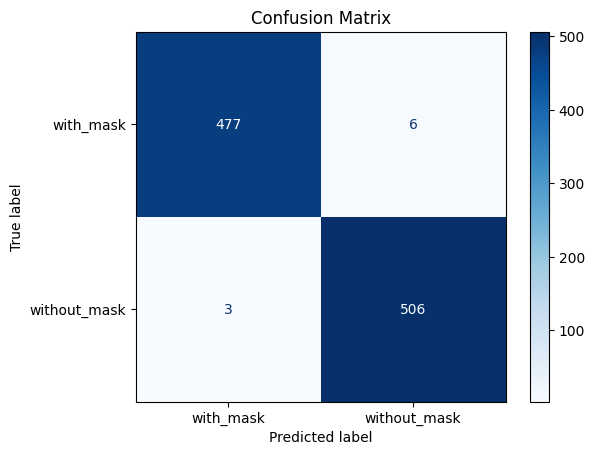

In [22]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

cm = confusion_matrix(all_labels, all_preds)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=train_dataset.classes)
disp.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

## Classification Report

We compute precision, recall, and F1-score for each class.

In [23]:
report = classification_report(
    all_labels,
    all_preds,
    target_names=train_dataset.classes,
    digits=4
)

print(report)

              precision    recall  f1-score   support

   with_mask     0.9938    0.9876    0.9907       483
without_mask     0.9883    0.9941    0.9912       509

    accuracy                         0.9909       992
   macro avg     0.9910    0.9908    0.9909       992
weighted avg     0.9909    0.9909    0.9909       992



## Per-Class Accuracy

We calculate the accuracy for each class separately.

In [24]:
class_names = train_dataset.classes
cm = confusion_matrix(all_labels, all_preds)

per_class_acc = cm.diagonal() / cm.sum(axis=1)

for i, acc in enumerate(per_class_acc):
    print(f"{class_names[i]} Accuracy: {acc:.4f}")

with_mask Accuracy: 0.9876
without_mask Accuracy: 0.9941


### Insight:
The model demonstrates excellent performance on the test set, achieving an overall accuracy of approximately 99%. The confusion matrix shows very few misclassifications, indicating that the model can effectively distinguish between masked and unmasked faces.

Both classes have high precision, recall, and F1-scores, with balanced performance across categories. The per-class accuracy further confirms that the model generalizes well and does not exhibit bias toward any class.

These results indicate that the model is robust and reliable for real-world face mask detection tasks.

## Misclassification Analysis

We analyze incorrectly classified samples to understand model limitations.

In [25]:
import numpy as np

misclassified_indices = np.where(all_preds != all_labels)[0]

print("Number of misclassified samples:", len(misclassified_indices))

for i in misclassified_indices[:5]:
    print(f"True: {train_dataset.classes[all_labels[i]]} | Predicted: {train_dataset.classes[all_preds[i]]}")

Number of misclassified samples: 9
True: with_mask | Predicted: without_mask
True: with_mask | Predicted: without_mask
True: with_mask | Predicted: without_mask
True: with_mask | Predicted: without_mask
True: with_mask | Predicted: without_mask


### Insight:
A small number of misclassifications were observed. These errors may be caused by challenging cases such as unclear masks, unusual lighting, or low-quality images. Despite this, the overall error rate remains very low, indicating strong model performance.

# Conclusion

The project successfully developed a face mask detection system using transfer learning and FastAPI deployment.

The model achieved high accuracy and was validated on unseen data, demonstrating strong generalization.

Future work includes:
- Real-time detection
- Deployment with Docker
- Frontend integration